In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv(r"C:\Users\AsaatirPC\OneDrive\Desktop\housePrice.csv")
df

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
...,...,...,...,...,...,...,...,...
3474,86,2,True,True,True,Southern Janatabad,3.500000e+09,116666.67
3475,83,2,True,True,True,Niavaran,6.800000e+09,226666.67
3476,75,2,False,False,False,Parand,3.650000e+08,12166.67
3477,105,2,True,True,True,Dorous,5.600000e+09,186666.67


In [5]:
print(df.shape)
print(df.info())

(3479, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB
None


In [6]:
v=df.iloc[570]["Area"]
print(v)
print(type(v))
print(len(str(v)))
print(repr(v))

 3,310,000,000 
<class 'str'>
15
' 3,310,000,000 '


In [7]:
df["Area"]=df["Area"].replace("," , "")
df["Area"]=pd.to_numeric(df["Area"],errors="coerce")
df["Area"].dtype

dtype('float64')

In [8]:
nan_in_area=df["Area"].isnull().sum()
nan_in_price=df["Price(USD)"].isnull().sum()
nan_in_room=df["Room"].isnull().sum()
nan_in_parking=df["Parking"].isnull().sum()
nan_in_elevator=df["Elevator"].isnull().sum()
nan_in_warehouse=df["Warehouse"].isnull().sum()

print(nan_in_area , "\n" , nan_in_price)

6 
 0


In [9]:
df=df.dropna(subset=["Area" ,"Room","Parking" , "Elevator" , "Warehouse", "Price(USD)"])

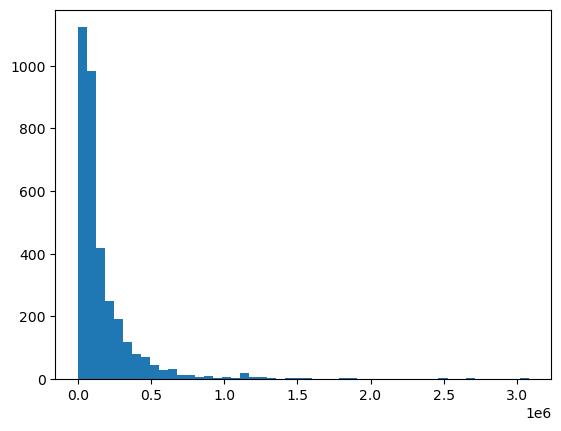

In [10]:
plt.hist(df["Price(USD)"] , bins=50)
plt.show()

In [11]:
feature=["Area" ,"Room" , "Parking" , "Warehouse", "Elevator" ]
X=df[feature].values.astype(float)
Y=df["Price(USD)"].values.astype(float)
X

array([[ 63.,   1.,   1.,   1.,   1.],
       [ 60.,   1.,   1.,   1.,   1.],
       [ 79.,   2.,   1.,   1.,   1.],
       ...,
       [ 75.,   2.,   0.,   0.,   0.],
       [105.,   2.,   1.,   1.,   1.],
       [ 82.,   2.,   0.,   1.,   1.]])

In [12]:
np.random.seed(42)
n=len(X)
indices=np.random.permutation(n)
split=int(0.8 * n)
train_idx=indices[ :split]
test_idx=indices[split: ]

X_train=X[train_idx]
Y_train=Y[train_idx]
X_test=X[test_idx]
Y_test=Y[test_idx]

print(type(X_train))
print(type(Y_train))

print(np.isnan(X_train).any())
print(np.isnan(Y_train).any())
print(X_train[:5])
print(Y_train[:5])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
False
False
[[145.   3.   1.   1.   1.]
 [ 97.   2.   1.   1.   1.]
 [125.   3.   1.   1.   1.]
 [ 55.   1.   1.   1.   1.]
 [ 74.   2.   1.   1.   1.]]
[ 58000.   129333.33 210000.    71666.67  56733.33]


In [13]:
ones_train=np.ones((X_train.shape[0],1))
X_train_with_bias=np.c_[ones_train , X_train]
theta=np.linalg.inv(X_train_with_bias.T @ X_train_with_bias) @ X_train_with_bias.T @ Y_train

b=theta[0]
w=theta[1]

ones_test=np.ones((X_test.shape[0] ,1))
x_test_with_bias=np.c_[ones_test , X_test]

y_pred=x_test_with_bias @ theta

print(f"w :{w}")
print(f"b :{b}")

w :2390.892692672208
b :-239523.96951723046


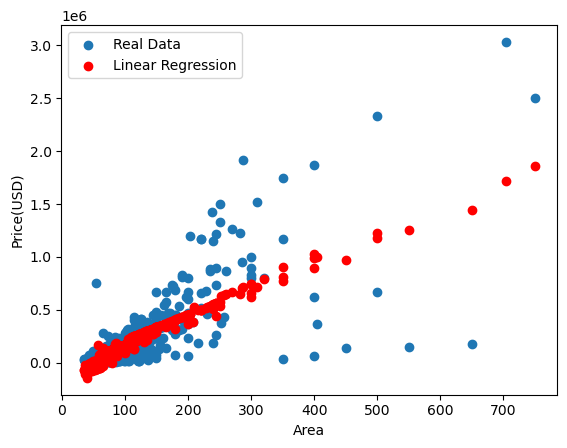

In [18]:
plt.scatter(X_test[: ,0] , Y_test , label="Real Data")
plt.scatter(X_test[:,0] , y_pred , color="red" , label="Linear Regression")
plt.xlabel("Area")
plt.ylabel("Price(USD)")
plt.legend()
plt.show()

In [15]:
mse=np.mean((y_pred - Y_test)**2)
mse

np.float64(36050861731.41288)

In [16]:
rmse=np.sqrt(mse)
rmse

np.float64(189870.64473323117)

In [17]:
mae=np.mean(np.abs(y_pred - Y_test))
mae

np.float64(100390.57248506624)